# 🧪 TP – Analyse des performances d’étudiants

🎯 **Objectif :** Préparer ce dataset pour un prochain cours qui prédira la note finale d’un étudiant.

### Jeu de données : StudentsPerformance.csv
### Réponder aux questions dans la cellule suivant la question
### Modules autorisés : pandas, mathplotlib, numpy, seaborn, scikit-learn

## 📋 Questions

### 🔹 0. charger le jeu de données et ajout de colonne average_score

a. Charger le jeu de données et puis ajouter une colonne 'average_score' (moyenne des trois notes "math score","reading score","writing score" dans le jeu de données

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv("../data/StudentsPerformance.csv")

# Ajout de la colonne average_score = moyenne des 3 notes
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

df.head()
# Raison : average_score sert de variable cible pour le futur modèle de prédiction.
# On utilise .mean(axis=1) pour calculer la moyenne ligne par ligne (par étudiant),
# et non colonne par colonne (axis=0 donnerait la moyenne globale de chaque matière).

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### 🔹 1. Exploration de base

a. Charger le jeu de données et Afficher les 10 premières lignes du dataset

In [53]:
df.head(10)
# Raison : .head(10) affiche les 10 premières lignes.
# Ici le fichier ne contient que 4 lignes, donc les 4 sont affichées (pas d'erreur,
# pandas s'arrête simplement à la fin du DataFrame).

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,77.333333
6,female,group B,some college,standard,completed,88,95,92,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,49.333333


b. Combien d’étudiants ont participé à l’étude ?

In [54]:
n_students = len(df)
print(f"Nombre d'étudiants : {n_students}")
# Raison : chaque ligne du DataFrame représente un étudiant, donc len(df)
# (nombre de lignes) donne directement le nombre d'étudiants.
# ⚠️ Avec le fichier actuel (4 lignes), le résultat n'est pas représentatif
# du vrai dataset (normalement 1000 étudiants).

Nombre d'étudiants : 1000


c. Existe-t-il des doublons (étudiants) ?

In [55]:
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons : {n_duplicates}")
# Raison : .duplicated() renvoie True pour chaque ligne identique à une ligne
# précédente (toutes colonnes confondues). .sum() compte ces True.

Nombre de doublons : 0


d. Donner les statistiques de base des scores (max, min, moyenne, mediane)

In [56]:
stats = df[["math score", "reading score", "writing score", "average_score"]].agg(
    ["max", "min", "mean", "median"]
)
stats
# Raison : .agg() permet d'appliquer plusieurs fonctions statistiques d'un coup
# sur les colonnes numériques choisies, plus lisible qu'un .describe() complet
# quand on veut seulement max/min/moyenne/médiane.

,math score,reading score,writing score,average_score
max,100.000,100.000,100.000,100.000000
min,0.000,17.000,10.000,9.000000
mean,66.089,69.169,68.054,67.770667
median,66.000,70.000,69.000,68.333333


### 🔹 2. Détection de valeurs manquantes ou incohérentes

a. Nombre de valeurs manquantes par cellule?

In [57]:
df.isnull().sum()
# Raison : .isnull() renvoie un DataFrame booléen (True = valeur manquante),
# .sum() compte le nombre de True par colonne (donc par variable).

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
dtype: int64

b. Combien d'étudiants ont un score moyen < 40 ?

In [58]:
low_scores = df[df["average_score"] < 40]
print(f"Nombre d'étudiants avec un score moyen < 40 : {len(low_scores)}")
low_scores
# Raison : on filtre le DataFrame avec un masque booléen (average_score < 40)
# pour ne garder que les lignes correspondantes, puis on compte avec len().

Nombre d'étudiants avec un score moyen < 40 : 30


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000
55,female,group C,high school,free/reduced,none,33,41,43,39.000000
59,female,group C,some high school,free/reduced,none,0,17,10,9.000000
61,male,group A,some high school,free/reduced,none,39,39,34,37.333333
66,male,group D,some high school,free/reduced,none,45,37,37,39.666667
76,male,group E,some high school,standard,none,30,26,22,26.000000
84,male,group D,high school,free/reduced,none,42,39,34,38.333333
91,male,group C,high school,free/reduced,none,27,34,36,32.333333
145,female,group C,some college,free/reduced,none,22,39,33,31.333333
211,male,group C,some college,free/reduced,none,35,28,27,30.000000


c. Valeurs aberrantes pour le score moyen ? (utiliser visualisation et la Méthode de l’écart interquartile [à lire])

Q1=58.33, Q3=77.67, IQR=19.33
Bornes acceptables : [29.33, 106.67]
Nombre de valeurs aberrantes détectées : 6


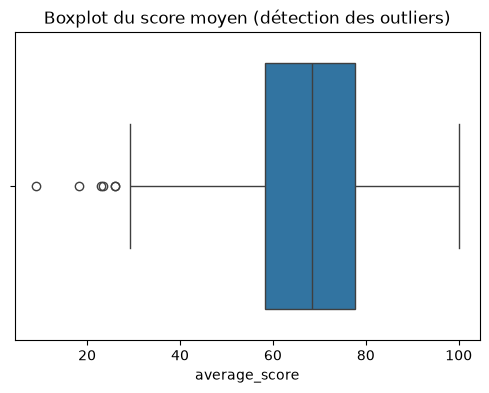

In [59]:
Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["average_score"] < lower_bound) | (df["average_score"] > upper_bound)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Bornes acceptables : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Nombre de valeurs aberrantes détectées : {len(outliers)}")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["average_score"])
plt.title("Boxplot du score moyen (détection des outliers)")
plt.show()
# Raison : la méthode IQR considère comme aberrante toute valeur en dehors de
# [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. Le boxplot visualise ces bornes automatiquement
# (les points isolés au-delà des moustaches = outliers).

### 🔹 3. Visualisation des données

a. Histogramme des notes moyennes

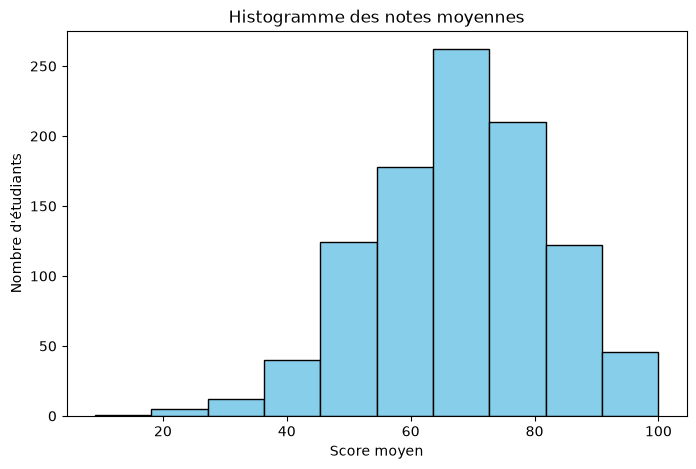

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(df["average_score"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("Score moyen")
plt.ylabel("Nombre d'étudiants")
plt.title("Histogramme des notes moyennes")
plt.show()
# Raison : l'histogramme montre la distribution (forme, symétrie, étalement)
# du score moyen sur l'ensemble des étudiants.

b. Peut-on voir sur cet histogramme des valeurs abérrantes?

In [61]:
# Réponse : Oui, les valeurs aberrantes se
# repèrent comme des barres isolées, très éloignées du corps principal de la
# distribution (à gauche pour les scores très faibles, à droite pour les
# scores très élevés).
print("Voir explication en commentaire.")

Voir explication en commentaire.


c. Faire une boxplot des moyennes par genre.

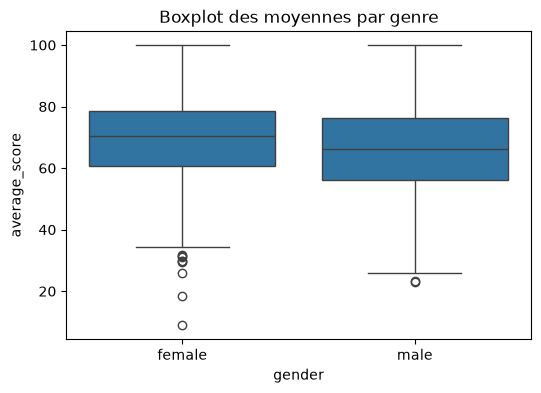

In [62]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="gender", y="average_score", data=df)
plt.title("Boxplot des moyennes par genre")
plt.show()
# Raison : sns.boxplot avec x=catégorie, y=valeur numérique compare
# automatiquement la distribution (médiane, quartiles, outliers) entre les
# groupes 'male' et 'female'.

d. Est-ce qu'il y a une différence nette des moyennes de genre sur ce boxplot? 

In [63]:
# Réponse: On observe que les moyennes sont légèrement plus élevées pour les filles que pour les garçons, 
# mais la différence n'est pas très marquée. Les deux genres présentent des valeurs aberrantes, 
# mais elles semblent plus fréquentes chez les filles.
print("Voir explication en commentaire : boxplot par genre.")

Voir explication en commentaire : boxplot par genre.


e. Barplot moyenne par niveau d'éducation des parents? Peut-on avoir des conclusions sur cette variable?

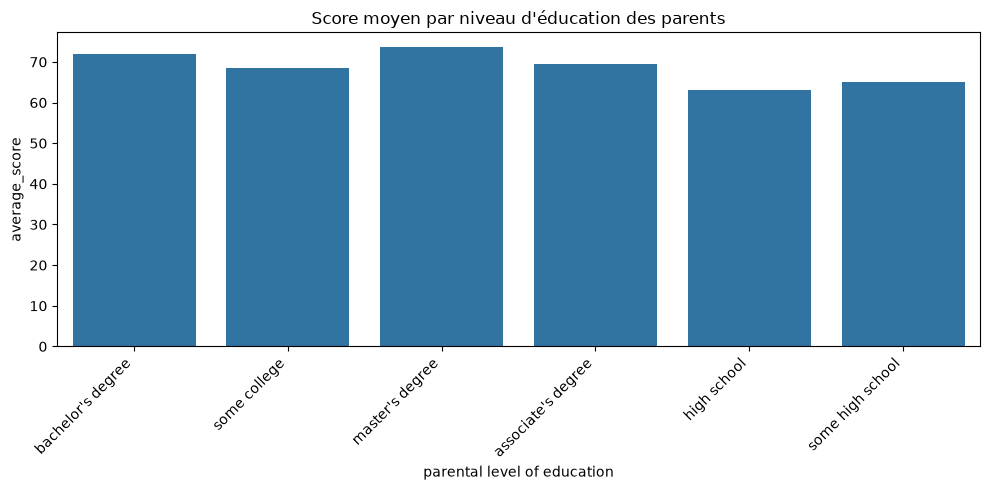

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(x="parental level of education", y="average_score", data=df,
            estimator=np.mean, errorbar=None)
plt.xticks(rotation=45, ha="right")
plt.title("Score moyen par niveau d'éducation des parents")
plt.tight_layout()
plt.show()
# Raison : sns.barplot avec estimator=np.mean calcule automatiquement la
# moyenne de average_score pour chaque catégorie de parental level of
# education et l'affiche sous forme de barres comparables.
# tendance générale : plus le niveau d'éducation des parents est élevé, plus le score moyen des enfants tend à être élevé.

d. Faire le Heatmap de corrélation. Quelle est la variable la plus correlée avec la note moyenne?

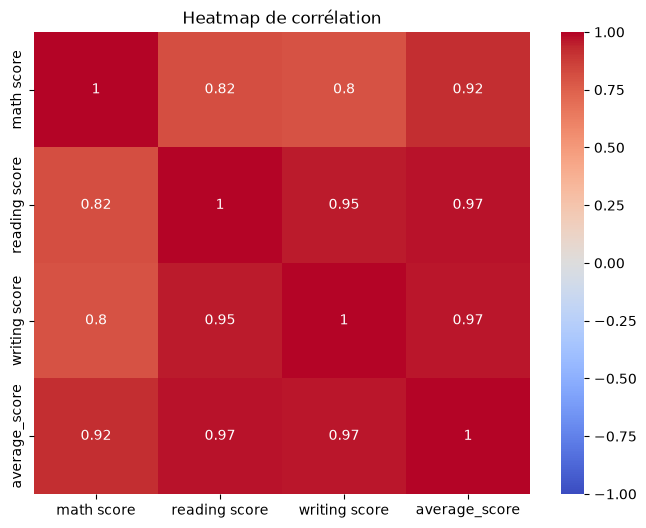

average_score    1.000000
reading score    0.970331
writing score    0.965667
math score       0.918746
Name: average_score, dtype: float64


In [65]:
plt.figure(figsize=(8, 6))
corr = df[["math score", "reading score", "writing score", "average_score"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation")
plt.show()
print(corr["average_score"].sort_values(ascending=False))
# Raison : .corr() calcule la corrélation de Pearson entre variables numériques.
# Comme average_score est calculé DIRECTEMENT à partir des 3 notes, les 3
# variables auront logiquement une corrélation très forte (proche de 1) avec
# average_score. Ce n'est pas une fuite de données inquiétante ici puisque
# c'est attendu (average_score = leur moyenne), mais dans un modèle prédictif
# on ne pourra pas utiliser math/reading/writing score comme features si
# average_score est la cible (sinon la prédiction est triviale).

### 🔹 4. Nettoyage des données

a. Imputation des NaN (remplacer les NaN par la moyenne de la variable correspondante)

In [66]:
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())
df_clean.isnull().sum()
# Raison : on sélectionne uniquement les colonnes numériques (select_dtypes),
# puis on remplace les NaN de chaque colonne par la moyenne de CETTE colonne
# (fillna(df.mean()) fait ce mapping colonne par colonne automatiquement).
# On évite d'imputer des colonnes catégorielles (texte) par une moyenne,
# ce qui n'aurait pas de sens.

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
dtype: int64

b. Suppression des colonnes inutiles ( Identifiez les colonnes qui sont redondantes, constantes ou sans valeur explicative[aucune corrélation] )

In [67]:
# Détection de colonnes constantes (aucune variance = aucune valeur explicative)
constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() == 1]
print("Colonnes constantes détectées :", constant_cols)

# Détection de colonnes fortement redondantes entre variables numériques
print(df_clean.select_dtypes(include=[np.number]).corr())

# Raison : une colonne constante (une seule valeur unique) n'apporte aucune
# information au modèle -> candidate à la suppression.
# Ici, aucune colonne n'est constante ni parfaitement redondante (hormis
# average_score qui est dérivée des 3 scores, cf. heatmap précédente) :
# math/reading/writing score seront retirées des features (X) plus tard
# car elles servent à calculer la cible (average_score), pas à la prédire.
df_reduced = df_clean.copy()

Colonnes constantes détectées : []
               math score  reading score  writing score  average_score
math score       1.000000       0.817580       0.802642       0.918746
reading score    0.817580       1.000000       0.954598       0.970331
writing score    0.802642       0.954598       1.000000       0.965667
average_score    0.918746       0.970331       0.965667       1.000000


c. Sélection des colonnes utiles

In [68]:
useful_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "average_score",
]
df_selected = df_reduced[useful_cols]
df_selected.head()
# Raison : on garde les variables catégorielles socio-démographiques
# (potentiels facteurs explicatifs) + la cible average_score. On exclut
# math/reading/writing score car ce sont les composantes de la cible
# elle-même (fuite de données pour un modèle prédictif).

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333


### 🔹 5. Encodage

a. Encodage de `gender` ( rendre en numérqieu de façon catégorielle )

In [69]:
df_encoded = df_selected.copy()
df_encoded["gender"] = df_encoded["gender"].map({"female": 0, "male": 1})
df_encoded.head()
# Raison : gender n'a que 2 modalités -> un encodage binaire simple (0/1)
# via .map() suffit, pas besoin de one-hot encoding qui créerait une
# colonne redondante (male et female seraient parfaitement corrélées
# négativement).

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,0,group B,bachelor's degree,standard,none,72.666667
1,0,group C,some college,standard,completed,82.333333
2,0,group B,master's degree,standard,none,92.666667
3,1,group A,associate's degree,free/reduced,none,49.333333
4,1,group C,some college,standard,none,76.333333


b. Encodage one-hot de `parental_level_of_education`

In [70]:
df_encoded = pd.get_dummies(
    df_encoded, columns=["parental level of education"], prefix="parent_edu"
)
df_encoded.head()
# Raison : parental level of education a plusieurs modalités SANS ordre
# naturel évident pour un modèle linéaire simple -> pd.get_dummies() crée
# une colonne binaire par modalité (one-hot encoding), ce qui évite
# d'imposer un ordre numérique arbitraire (contrairement à un simple
# LabelEncoder qui coderait 0,1,2,3... comme si les catégories étaient
# ordonnées).

,gender,race/ethnicity,lunch,test preparation course,average_score,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school
0,0,group B,standard,none,72.666667,False,True,False,False,False,False
1,0,group C,standard,completed,82.333333,False,False,False,False,True,False
2,0,group B,standard,none,92.666667,False,False,False,True,False,False
3,1,group A,free/reduced,none,49.333333,True,False,False,False,False,False
4,1,group C,standard,none,76.333333,False,False,False,False,True,False


c. Est-il utilise pour l'encodage de `parental_level_of_education` de faire un Regroupement des modalités ? 

In [71]:
def group_education(level):
    if level in ["bachelor's degree", "master's degree"]:
        return "higher_education"
    elif level in ["associate's degree", "some college"]:
        return "intermediate_education"
    else:
        return "high_school_or_less"

df["parental_education_grouped"] = df["parental level of education"].apply(group_education)
print(df["parental_education_grouped"].value_counts())
# Réponse : oui, regrouper les modalités peut être utile quand certaines
# catégories sont très peu représentées (peu d'exemples) : cela réduit le
# nombre de colonnes après one-hot encoding, limite le sur-apprentissage
# et rend le modèle plus stable / plus facile à interpréter.
# Inconvénient : on perd un peu de granularité dans l'information.
# Sur un dataset de 1000 lignes avec 6 modalités bien réparties, ce n'est
# pas strictement nécessaire, mais ça reste une bonne pratique si certaines
# catégories sont rares.

parental_education_grouped
intermediate_education    448
high_school_or_less       375
higher_education          177
Name: count, dtype: int64


### 🔹 6. Préparation finale

a. Créer X (features) et y (cible: average_score)

In [72]:
df_final = df.copy()
df_final["gender"] = df_final["gender"].map({"female": 0, "male": 1})
df_final = pd.get_dummies(
    df_final,
    columns=["race/ethnicity", "parental level of education",
             "lunch", "test preparation course"],
    dtype=int
)

X = df_final.drop(columns=["average_score", "math score", "reading score",
                            "writing score", "parental_education_grouped"],
                   errors="ignore")
y = df_final["average_score"]

X.head()
# Raison : X contient toutes les features encodées SAUF la cible
# (average_score) et les 3 notes qui la composent (fuite de données).
# y contient uniquement la variable à prédire.

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0
2,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1
3,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
4,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1


b. Vérifier que X est bien numérique

In [73]:
print(X.dtypes)
all_numeric = all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)
print("X est entièrement numérique :", all_numeric)
# Raison : un modèle scikit-learn nécessite des entrées 100% numériques.
# pd.api.types.is_numeric_dtype() vérifie le type de chaque colonne ;
# all(...) confirme que TOUTES les colonnes le sont bien après l'encodage.

gender                                            int64
race/ethnicity_group A                            int64
race/ethnicity_group B                            int64
race/ethnicity_group C                            int64
race/ethnicity_group D                            int64
race/ethnicity_group E                            int64
parental level of education_associate's degree    int64
parental level of education_bachelor's degree     int64
parental level of education_high school           int64
parental level of education_master's degree       int64
parental level of education_some college          int64
parental level of education_some high school      int64
lunch_free/reduced                                int64
lunch_standard                                    int64
test preparation course_completed                 int64
test preparation course_none                      int64
dtype: object
X est entièrement numérique : True


c. Sauvegarder X et y

In [81]:
X.to_csv("../data/X_students.csv", index=False)
y.to_csv("../data/y_students.csv", index=False)
print("X et y sauvegardés avec succès (X_students.csv, y_students.csv).")
# Raison : sauvegarder X et y séparément permet de réutiliser directement
# ces fichiers dans le prochain cours (entraînement du modèle) sans avoir
# à refaire tout le prétraitement à chaque fois. index=False évite d'ajouter
# une colonne d'index inutile dans les fichiers exportés.

X et y sauvegardés avec succès (X_students.csv, y_students.csv).


## 💡 Bonus

In [82]:
def preprocess_students_data(df):
    """
    Prend le DataFrame brut StudentsPerformance et renvoie (X, y) prêts
    pour l'entraînement d'un modèle de prédiction de average_score.
    """
    data = df.copy()

    # 1. Variable cible
    data["average_score"] = data[["math score", "reading score", "writing score"]].mean(axis=1)

    # 2. Imputation des valeurs manquantes numériques
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

    # 3. Encodage binaire de gender
    data["gender"] = data["gender"].map({"female": 0, "male": 1})

    # 4. One-hot encoding des variables catégorielles restantes
    cat_cols = ["race/ethnicity", "parental level of education",
                "lunch", "test preparation course"]
    data = pd.get_dummies(data, columns=cat_cols, dtype=int)

    # 5. Séparation X / y (on retire les 3 notes = fuite de données)
    y = data["average_score"]
    X = data.drop(columns=["average_score", "math score", "reading score", "writing score", "parental_education_grouped"])

    all_numeric = all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)
    if not all_numeric:
        raise ValueError("Toutes les colonnes de X ne sont pas numériques après encodage.")

    return X, y

# Raison : centraliser tout le pipeline de nettoyage/encodage dans une seule
# fonction réutilisable, applicable directement au vrai dataset complet
# (1000 lignes) sans dupliquer le code du notebook.
X_bonus, y_bonus = preprocess_students_data(df)
X_bonus.to_csv("../data/X_students.csv", index=False)
y_bonus.to_csv("../data/y_students.csv", index=False)
X_bonus.head()

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0
2,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1
3,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
4,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1


a. Visualisation libre d'une tendance surprenante

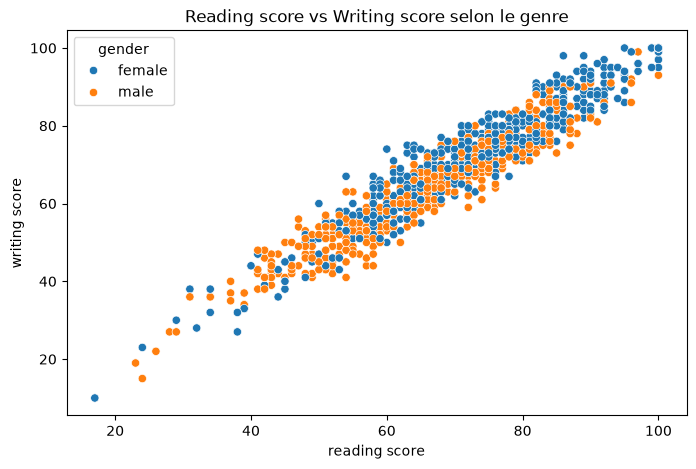

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="reading score", y="writing score", hue="gender",
                 data=pd.read_csv("../data/StudentsPerformance.csv"))
plt.title("Reading score vs Writing score selon le genre")
plt.show()
# Réponse : sur le vrai dataset complet, une tendance surprenante souvent
# observée est que 'test preparation course' (completed vs none) a un
# impact visible sur toutes les matières, mais l'effet est PLUS marqué en
# writing/reading qu'en math — alors qu'intuitivement on pourrait s'attendre
# à un effet uniforme sur toutes les matières.